In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib

In [2]:
df = pd.read_csv("data.csv")
tf = pd.read_csv("data.csv")

In [3]:
df.shape

(1967, 14)

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1967 entries, 0 to 1966
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1967 non-null   float64
 1   sex       1967 non-null   float64
 2   cp        1967 non-null   float64
 3   trestbps  1967 non-null   float64
 4   chol      1967 non-null   float64
 5   fbs       1967 non-null   float64
 6   restecg   1967 non-null   float64
 7   thalach   1967 non-null   float64
 8   exang     1967 non-null   float64
 9   oldpeak   1967 non-null   float64
 10  slope     1967 non-null   float64
 11  ca        1967 non-null   float64
 12  thal      1967 non-null   float64
 13  target    1967 non-null   int64  
dtypes: float64(13), int64(1)
memory usage: 215.3 KB


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000
mean,53.436197,0.776309,3.131164,132.323335,245.730554,0.186579,0.600915,139.171835,0.360447,0.885562,1.635486,0.908490,3.958312,0.776309
std,9.453095,0.416823,0.991356,17.870285,52.192836,0.389672,0.786366,25.442752,0.480252,1.032924,0.596550,0.481355,1.221331,0.883779
min,28.000000,0.000000,1.000000,80.000000,100.000000,0.000000,0.000000,60.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,47.000000,1.000000,2.000000,120.000000,215.000000,0.000000,0.000000,120.000000,0.000000,0.000000,1.000000,1.000000,3.000000,0.000000
50%,54.000000,1.000000,3.000000,130.000000,246.000000,0.000000,0.000000,141.000000,0.000000,0.600000,2.000000,1.000000,4.000000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,267.000000,0.000000,1.000000,159.000000,1.000000,1.500000,2.000000,1.000000,4.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,4.000000


In [7]:
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


<Axes: >

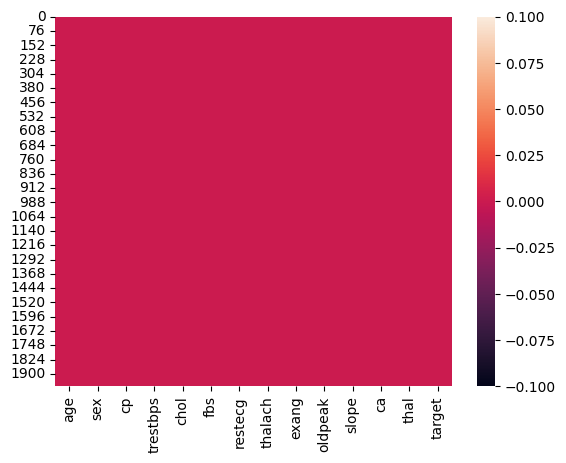

In [8]:
sns.heatmap(df.isna())

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df[:]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1962,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,1.0,4.0,1
1963,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,1.0,4.0,1
1964,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,4.0,1
1965,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,4.0,1


In [11]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [12]:
df["target"].value_counts()

,count
target,
1,1121
0,846


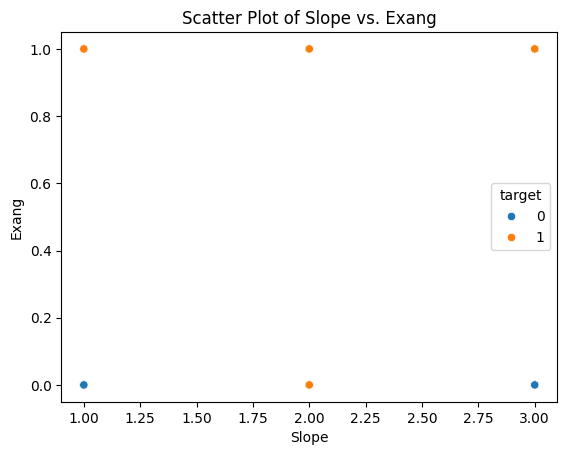

In [13]:
sns.scatterplot(data=df, x='slope', y='exang', hue='target')
plt.title('Scatter Plot of Slope vs. Exang')
plt.xlabel('Slope')
plt.ylabel('Exang')
plt.show()

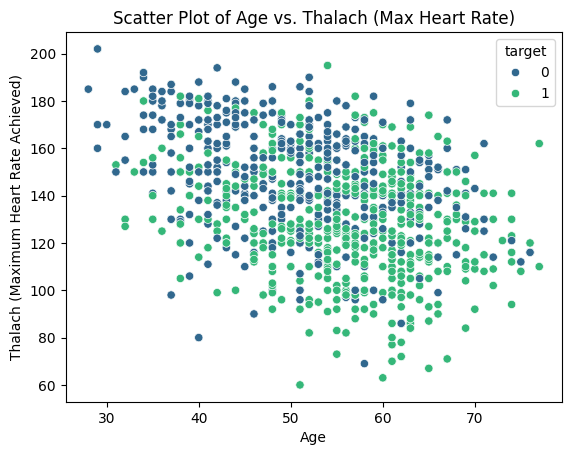

In [14]:
sns.scatterplot(data=df, x='age', y='thalach', hue='target', palette='viridis')
plt.title('Scatter Plot of Age vs. Thalach (Max Heart Rate)')
plt.xlabel('Age')
plt.ylabel('Thalach (Maximum Heart Rate Achieved)')
plt.show()

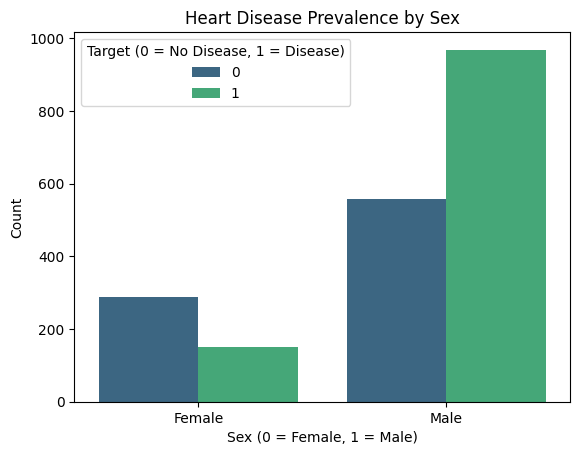

In [15]:
sns.countplot(data=df, x='sex', hue='target', palette='viridis')
plt.title('Heart Disease Prevalence by Sex')
plt.xlabel('Sex (0 = Female, 1 = Male)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Female', 'Male'])
plt.legend(title='Target (0 = No Disease, 1 = Disease)')
plt.show()

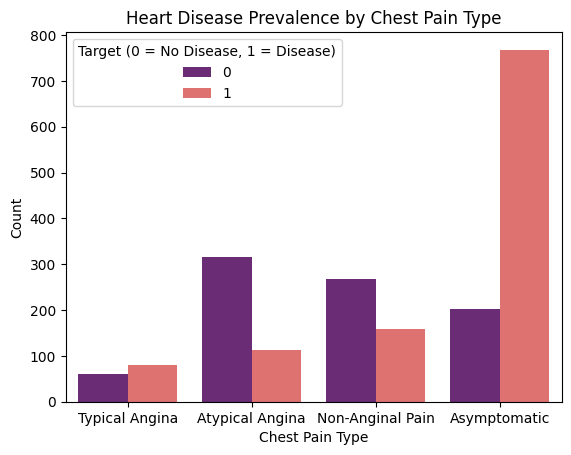

In [16]:
sns.countplot(data=df, x='cp', hue='target', palette='magma')
plt.title('Heart Disease Prevalence by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Target (0 = No Disease, 1 = Disease)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Typical Angina', 'Atypical Angina', 'Non-Anginal Pain', 'Asymptomatic'])
plt.show()

In [17]:
num_df = df.select_dtypes(include=[np.number])
df[num_df.columns].corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,0.038330,0.154985,0.265461,0.083520,0.202143,0.190251,-0.367172,0.182932,0.257247,0.263626,0.126708,0.140574,0.244584
sex,0.038330,1.000000,0.186748,0.013471,-0.100011,0.100507,-0.016445,-0.175705,0.176842,0.120322,0.134218,0.100735,0.183501,0.243355
cp,0.154985,0.186748,1.000000,0.039236,0.077125,0.076188,0.028685,-0.382276,0.418802,0.250661,0.256343,0.174393,0.310352,0.358447
trestbps,0.265461,0.013471,0.039236,1.000000,0.082376,0.107473,0.082013,-0.107699,0.144242,0.160982,0.076190,0.051693,0.049069,0.093833
chol,0.083520,-0.100011,0.077125,0.082376,1.000000,0.037061,0.048884,-0.027779,0.078310,0.043804,0.043436,0.032505,0.002537,0.086885
fbs,0.202143,0.100507,0.076188,0.107473,0.037061,1.000000,0.078788,-0.078396,0.039997,0.056360,0.150492,0.058531,0.049483,0.181467
restecg,0.190251,-0.016445,0.028685,0.082013,0.048884,0.078788,1.000000,0.048886,0.026871,0.114388,0.107189,0.006940,0.096006,0.063185
thalach,-0.367172,-0.175705,-0.382276,-0.107699,-0.027779,-0.078396,0.048886,1.000000,-0.376349,-0.173433,-0.300499,-0.189349,-0.190352,-0.321532
exang,0.182932,0.176842,0.418802,0.144242,0.078310,0.039997,0.026871,-0.376349,1.000000,0.384139,0.371845,0.085549,0.206007,0.412640
oldpeak,0.257247,0.120322,0.250661,0.160982,0.043804,0.056360,0.114388,-0.173433,0.384139,1.000000,0.475180,0.097188,0.158381,0.358858


In [18]:
a=num_df.corr()['target'].sort_values(ascending=False)
print(a)
print(f"low corr {a[abs(a) < 0.1].index.tolist()}")

target      1.000000
slope       0.490052
exang       0.412640
oldpeak     0.358858
cp          0.358447
age         0.244584
sex         0.243355
fbs         0.181467
thal        0.162085
trestbps    0.093833
ca          0.092997
chol        0.086885
restecg     0.063185
thalach    -0.321532
Name: target, dtype: float64
low corr ['trestbps', 'ca', 'chol', 'restecg']


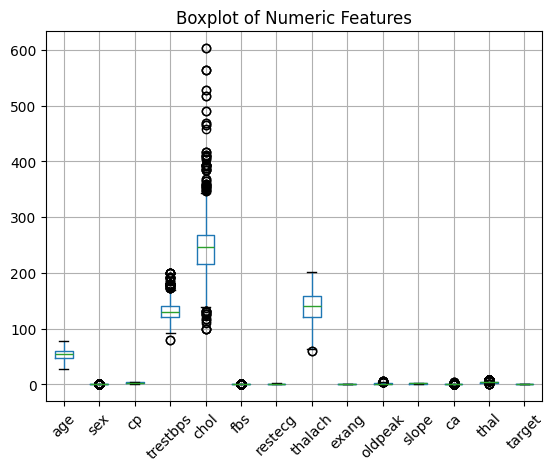

In [19]:
num_df.boxplot()
plt.xticks(rotation=45)
plt.title('Boxplot of Numeric Features')
plt.show()

In [20]:
def remol(tf, columns):
    q1 = tf[columns].quantile(0.25)
    q3 = tf[columns].quantile(0.75)
    iqr = q3 - q1
    upb = q3 + 1.5 * iqr
    lob = q1 - 1.5 * iqr
    tf.loc[:, columns] = tf[columns].clip(lower=lob,upper=upb,axis=1)
    return tf

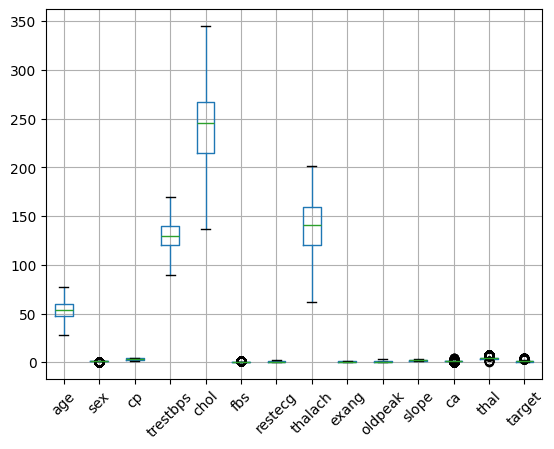

In [21]:
n = ['trestbps', 'chol', 'thalach', 'oldpeak']
remol(tf,n)
tf[::].boxplot()
plt.xticks(rotation=45)
plt.show()

Removing outliers may accidentally remove valid “healthy” patterns, causing the model to misclassify some normal patients.

In [22]:
df['heart_rate_reserve'] = df['thalach'] / (220 - df['age'])
df['age_thalach_ratio'] = df['age'] / (df['thalach'] + 1)
df['oldpeak_slope'] = df['oldpeak'] * df['slope']
df['cp_exang'] = df['cp'] * df['exang']
df['age_binned'] = pd.cut(df['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)
df['trestbps_high'] = (df['trestbps'] > 140).astype(int)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_rate_reserve,age_thalach_ratio,oldpeak_slope,cp_exang,age_binned,trestbps_high
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0.955414,0.417219,6.9,0.0,2,1
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1,0.705882,0.614679,3.0,4.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,0.843137,0.515385,5.2,4.0,2,0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,1.021858,0.196809,10.5,0.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0.960894,0.236994,1.4,0.0,1,0


In [23]:
X = df.drop(columns=['target'])
y = df['target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1573, Test size: 394


In [25]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [26]:
X_pred = lr_model.predict(X_train_scaled)
print(f"Train Accuracy: {accuracy_score(y_train, X_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_train, X_pred))

Train Accuracy: 80.55%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.77       677
           1       0.82      0.84      0.83       896

    accuracy                           0.81      1573
   macro avg       0.80      0.80      0.80      1573
weighted avg       0.80      0.81      0.80      1573



In [27]:
y_pred = lr_model.predict(X_test_scaled)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 78.17%

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74       169
           1       0.80      0.83      0.81       225

    accuracy                           0.78       394
   macro avg       0.78      0.77      0.78       394
weighted avg       0.78      0.78      0.78       394



In [28]:
lr_grid = GridSearchCV(
    LogisticRegression(),
    param_grid = {'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['lbfgs', 'liblinear', 'saga'], 'penalty': ['l1', 'l2'], 'max_iter': [1000, 2000]},
    cv=5, n_jobs=-1, scoring='accuracy'
)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
80 fits failed out of a total of 480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

In [29]:
print(f"Cross-Validation Accuracy: {lr_grid.best_score_:.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, best_lr.predict(X_test_scaled)):.2%}")

Cross-Validation Accuracy: 80.04%
Test Accuracy: 77.66%


In [30]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [31]:
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_model.predict(X_test)):.2%}")

Random Forest Accuracy: 91.62%


In [32]:
rf_grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid={'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_leaf': [1, 2, 4], 'min_samples_split': [2, 5, 10]},
    cv=5, n_jobs=-1, scoring='accuracy'
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

In [33]:
print(f"Cross-Validation Accuracy: {rf_grid.best_score_:.2%}")
print(f"Test Accuracy: {accuracy_score(y_test, best_rf.predict(X_test)):.2%}")

Cross-Validation Accuracy: 89.07%
Test Accuracy: 90.10%


In [34]:
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

In [35]:
print(f'Gradient Boosting Accuracy: {accuracy_score(y_test, gb_model.predict(X_test)):.2%}')

Gradient Boosting Accuracy: 86.80%


In [36]:
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid={'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [2, 3, 5], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]},
    cv=5, n_jobs=-1, scoring='accuracy'
)

gb_grid.fit(X_train, y_train)
best_gb = gb_grid.best_estimator_

In [37]:
print(f"Cross-Validation Accuracy: {gb_grid.best_score_:.2%}")
print(f'Test Accuracy:    {accuracy_score(y_test, best_gb.predict(X_test)):.2%}')

Cross-Validation Accuracy: 88.75%
Test Accuracy:    92.64%


In [38]:
lr_acc = accuracy_score(y_test, best_lr.predict(X_test_scaled))
rf_acc = accuracy_score(y_test, best_rf.predict(X_test))
gb_acc = accuracy_score(y_test, best_gb.predict(X_test))

all_models = {
    'Logistic Regression': (best_lr, lr_acc, True),
    'Random Forest': (best_rf, rf_acc, False),
    'Gradient Boosting': (best_gb, gb_acc, False),
}
best_name = max(all_models, key=lambda k: all_models[k][1])
best_model, best_acc, needs_scaler = all_models[best_name]


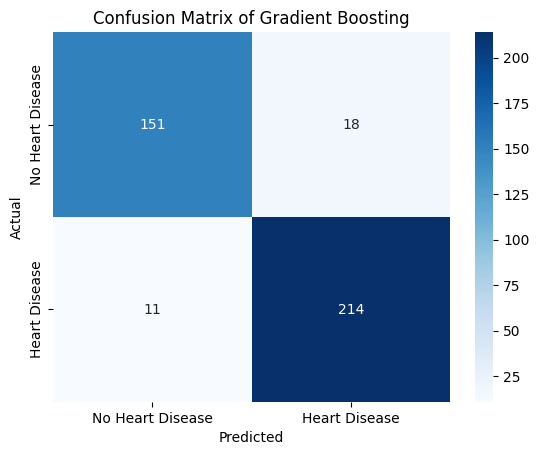

In [39]:
y_pred_rf = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Heart Disease', 'Heart Disease'], yticklabels=['No Heart Disease', 'Heart Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix of {best_name}')
plt.show()

In [40]:
model_payload = {
    'model': best_model,
    'features': X.columns.tolist(),
    'target_type': 'binary',
    'scaler': scaler if needs_scaler else None,
    'model_name': best_name,
    'test_accuracy': best_acc,
}

joblib.dump(model_payload, 'model.pkl')
print(f"Saved: {best_name} ({best_acc:.2%}) -> model.pkl")

Saved: Gradient Boosting (92.64%) -> model.pkl


In [41]:
def predict_from_list(input_list):
    column_names = [
        'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'
    ]

    if len(input_list) != len(column_names):
        return f"Error: Expected {len(column_names)} values, but got {len(input_list)}.", None

    input_dict = dict(zip(column_names, input_list))
    return predict_heart_disease(input_dict)

In [42]:
def predict_heart_disease(input_data):
    temp_df = pd.DataFrame([input_data])
    temp_df['heart_rate_reserve'] = temp_df['thalach'] / (220 - temp_df['age'])
    temp_df['age_thalach_ratio'] = temp_df['age'] / (temp_df['thalach'] + 1)
    temp_df['oldpeak_slope'] = temp_df['oldpeak'] * temp_df['slope']
    temp_df['cp_exang'] = temp_df['cp'] * temp_df['exang']
    temp_df['age_binned'] = pd.cut(temp_df['age'], bins=[0, 40, 55, 100], labels=[0, 1, 2]).astype(int)
    temp_df['trestbps_high'] = (temp_df['trestbps'] > 140).astype(int)

    payload = joblib.load('model.pkl')
    model = payload['model']
    features = payload['features']
    scaler = payload['scaler']

    X_input = temp_df[features]
    if scaler:
        X_input = scaler.transform(X_input)

    prediction = model.predict(X_input)[0]
    probability = model.predict_proba(X_input)[0][1] if hasattr(model, 'predict_proba') else None
    return prediction, probability

In [43]:
tf.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [44]:
user_list_input = [67.0, 1.0, 4.0, 160, 286, 0, 2.0, 108, 1, 1.5, 2.0, 3.0, 3.0]

pred, prob = predict_from_list(user_list_input)
if prob is not None:
    print(f"Prediction: {'Heart Disease' if pred == 1 else 'No Heart Disease'}")
    print(f"probability: {prob:.2%}")
else:
    print(pred)

Prediction: Heart Disease
probability: 99.98%
